(-1.0, 2.0)

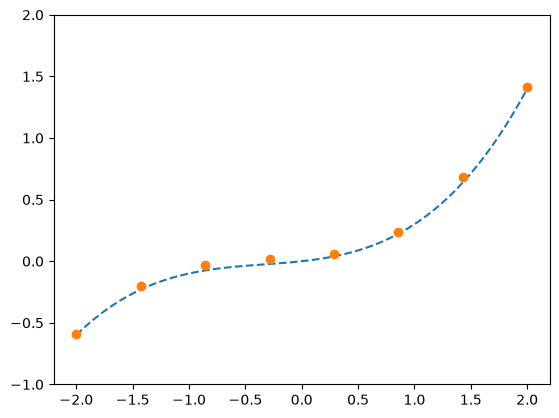

In [33]:
import numpy as np
import matplotlib.pyplot as plt

#真正的函数
def g(x):
    return 0.1 * (x ** 3 + x ** 2 + x)

#随意准备一些向真正的函数加入了一点噪声的训练数据
train_x = np.linspace(-2, 2, 8)
train_y = g(train_x) + np.random.rand(train_x.size) * 0.05

#绘图确认
x = np.linspace(-2, 2, 100)
plt.plot(x, g(x), linestyle = 'dashed')
plt.plot(train_x, train_y, 'o')
plt.ylim(-1, 2)

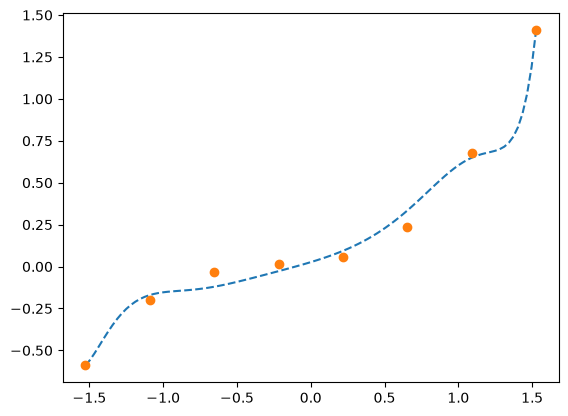

In [34]:
#标准化
mu = train_x.mean()
sigma = train_x.std()
def standardize(x):
    return (x - mu) / sigma

train_z = standardize(train_x)

#创建训练数据的矩阵
def to_matrix(x):
    x0 = np.ones(x.size)
    return np.vstack([
        x0,
        x,
        x ** 2,
        x ** 3,
        x ** 4,
        x ** 5,
        x ** 6,
        x ** 7,
        x ** 8,
        x ** 9,
        x ** 10
    ]).T

X = to_matrix(train_z)

#参数初始化
theta = np.random.rand(X.shape[1])

#预测函数
def f(x):
    return np.dot(x, theta)

#目标函数
def E(x, y):
    return 0.5 * np.sum((f(x) - y) ** 2)

#学习率
ETA = 1e-4

#误差
diff = 1

error = E(X, train_y)
while diff > 1e-6:
    theta = theta - ETA * np.dot(f(X) - train_y, X)
    current_error = E(X, train_y)
    diff = error - current_error
    error = current_error

#对结果绘图
z = standardize(x)
plt.plot(z, f(to_matrix(z)), linestyle = 'dashed')
plt.plot(train_z, train_y, 'o')
plt.show()




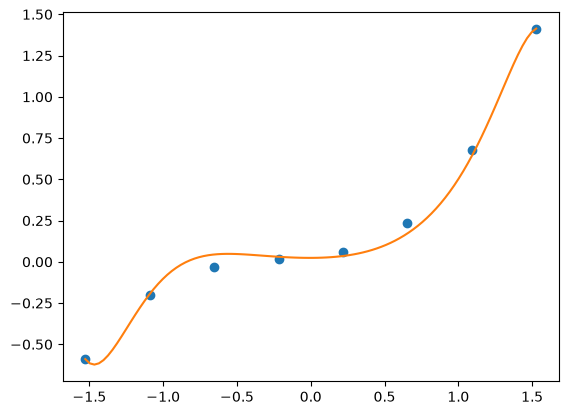

In [35]:
#保存未正则化的参数，然后再次参数初始化
theta1 = theta
theta = np.random.rand(X.shape[1])

#正则化常量
LAMBDA = 1

#误差
diff = 1

#重复学习（包含正则化项）
error  = E(X, train_y)
while diff > 1e-6:
    #正则化项。偏执项不适用正则化，所以为0
    reg_term = LAMBDA * np.hstack([0, theta[1:]])
    #应用正则化项，更新参数，为啥是LAMBDA * theta, 因为应用L2正则化的话目标函数加入的是0.5 * LAMBDA * (theta ** 2), 导数为LAMBDA * theta
    theta = theta - ETA * (np.dot(f(X) - train_y, X) + reg_term)
    current_error = E(X, train_y)
    diff = error - current_error
    error = current_error


#对结果绘图
plt.plot(train_z, train_y, 'o')
plt.plot(z, f(to_matrix(z)))
plt.show()



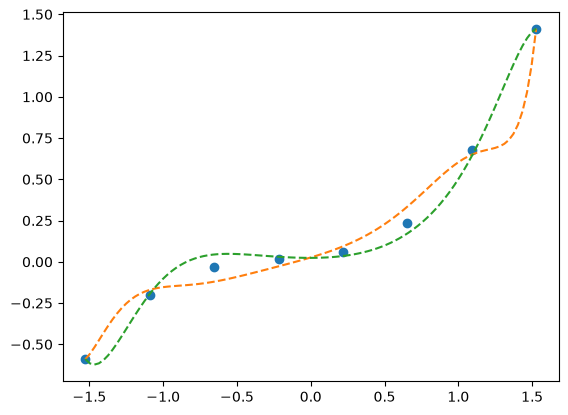

In [36]:
theta2 = theta
plt.plot(train_z, train_y, 'o')

#画出未应用正则化的结果
theta = theta1
plt.plot(z, f(to_matrix(z)), linestyle = 'dashed')

#画出应用了正则化的结果
theta = theta2
plt.plot(z, f(to_matrix(z)), linestyle = 'dashed')